EC ENG 232E - Summer 25 - Project 3

Team members:
*   Kaylee Lo (UID: 005-307-797), kayleelo@g.ucla.edu
*   Joanna Tang (UID: 602-503-690), joannat@g.ucla.edu
*   Rachel Zhang (UID: 705-413-148), rzhang319@g.ucla.edu

# A. Reinforcement Learning (RL) (160 pt)

In [ ]:
import numpy as np
import numpy.random as rn
import matplotlib.pyplot as plt
%matplotlib inline
!pip install ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.91 s (started: 2025-08-09 01:30:06 +00:00)


## 1) Environment set up

In [ ]:
# reference: https://github.com/prasenjit52282/GridWorld
# https://sbugallo.github.io/GridWorld-MDP/mdp.html
# https://www.youtube.com/watch?v=-suTQIcxItI
## Define the gridworld MDP class

class Gridworld(object):
    """
    Gridworld MDP.
    """

    def __init__(self, grid_size, wind, discount):
        """
        grid_size: Grid size. int.
        wind: Chance of moving randomly. float.
        discount: MDP discount. float.
        -> Gridworld
        """

        self.actions = ((1, 0), (0, 1), (-1, 0), (0, -1)) # right, down, left, up
        self.n_actions = len(self.actions)
        self.n_states = grid_size**2
        self.grid_size = grid_size
        self.wind = wind
        self.discount = discount

        # Preconstruct the transition probability array.
        self.transition_probability = np.array(
            [[[self._transition_probability(i, j, k)
               for k in range(self.n_states)]
              for j in range(self.n_actions)]
             for i in range(self.n_states)])

    def __str__(self):
        return "Gridworld({}, {}, {})".format(self.grid_size, self.wind,
                                              self.discount)

    def int_to_point(self, i):
        """
        Convert a state int into the corresponding coordinate.

        i: State int.
        -> (x, y) int tuple.
        """

        return (i % self.grid_size, i // self.grid_size)

    def point_to_int(self, p):
        """
        Convert a coordinate into the corresponding state int.

        p: (x, y) tuple.
        -> State int.
        """

        return int(p[0] + p[1]*self.grid_size)

    def neighbouring(self, i, k):
        """
        Get whether two points neighbour each other. Also returns true if they
        are the same point.

        i: (x, y) int tuple.
        k: (x, y) int tuple.
        -> bool.
        """

        return abs(i[0] - k[0]) + abs(i[1] - k[1]) <= 1

    # new helper methods
    def is_corner(self, xi, yi):
        return (xi == 0 and yi == 0) or \
               (xi == self.grid_size - 1 and yi == 0) or \
               (xi == 0 and yi == self.grid_size - 1) or \
               (xi == self.grid_size - 1 and yi == self.grid_size - 1)

    def is_edge (self, xi, yi):
        return (xi == 0 or xi == self.grid_size - 1) or \
               (yi == 0 or yi == self.grid_size - 1)

    def is_off_grid(self, i, j):
        xi, yi = self.int_to_point(i)
        xj, yj = self.actions[j]
        return not (0 <= xi + xj < self.grid_size and 0 <= yi + yj < self.grid_size)

    # 2.1.3 pg 3-6
    def _transition_probability(self, i, j, k):
        """
        Get the probability of transitioning from state i to state k given
        action j.

        i: State int.
        j: Action int.
        k: State int.
        -> p(s_k | s_i, a_j)
        """

        xi, yi = self.int_to_point(i)
        xj, yj = self.actions[j]
        xk, yk = self.int_to_point(k)


        if not self.neighbouring((xi, yi), (xk, yk)):
            return 0

        # Is k the intended state to move to?
        if (xi + xj, yi + yj) == (xk, yk):
            return 1 - self.wind + self.wind / self.n_actions

        # If these are not the same point, then we can move there by wind. #w/4
        if (xi, yi) != (xk, yk):
            return self.wind/ self.n_actions


        # If these are the same point, we can only move here by either moving
        # off the grid or being blown off the grid. Are we on a corner or not?
        if self.is_corner(xi, yi):
            # Corner.
            # Can move off the edge in two directions.
            # Did we intend to move off the grid?
            if self.is_off_grid(i, j):
                # we have the regular success chance of staying here
                # plus an extra chance of blowing onto the *other* off-grid square
                return 1 - self.wind * (self.n_actions-2)/ self.n_actions   # simplify 1 - w + 2w/4
            else:
                # We can blow off the grid in either direction only by wind. #w/4
                return 2 * self.wind/self.n_actions
        else:
            # Not a corner. Is it an edge?
            if not self.is_edge(xi, yi):
                return 0  # s=11, a=[0-3], cannot stay in place.

            else:#it is an edge
                # we Can only move off the edge in one direction.
                # Did we intend to move off the grid?
                if self.is_off_grid(i, j):
                    #we have the regular success chance of staying here.
                    return 1-self.wind*(self.n_actions-1)/self.n_actions    # simplify 1 - w + w/4
                else:
                    # We can blow off the grid only by wind.  #w/4
                    return self.wind/self.n_actions

    def reward(self, state_int):
        """
        Reward for being in state state_int.

        state_int: State integer. int.
        -> Reward.
        """

        positive_reward = 10
        negative_reward = -100

        pos_loc = {99}
        neg_loc = {14, 15, 24, 25, 28, 29, 38, 39, 52, 53, 62, 63}

        if state_int in pos_loc:
            return positive_reward/self.grid_size
        elif state_int in neg_loc:
            return negative_reward/self.grid_size
        else: return 0

    def reward2(self, state_int):
        """
        Reward for being in state state_int.

        state_int: State integer. int.
        -> Reward.
        """

        positive_reward = 10
        negative_reward = -100

        pos_loc = {99}
        neg_loc = {41,42,43,44,45,46,51,61,62,63,67,68,73,77,83,84,85,86,87}

        if state_int in pos_loc:
            return positive_reward
        elif state_int in neg_loc:
            return negative_reward
        else: return 0

time: 4.14 ms (started: 2025-08-09 01:30:10 +00:00)


- If state s′ and s are not neighboring states in the 2-D grid, then P(st+1 = s′|st = s, at = a) = 0, s′ and s are neighbors in the 2-D grid if you can move to s′ from s by taking an action a from the action set A. We will consider a state s to be a neighbor of itself.
For example, from figure 1 we can observe that states 1 and 11 are neighbors (we can transition from 1 to 11 by moving right) but states 1 and 12 are not neighbors.

- Each action corresponds to a movement in the intended direction with probability 1 − w, but has a probability of w of moving in a random direction instead due to wind. To illustrate this, let’s consider the states shown in figure 3

- If the agent is at one of the four corner states (0,9,90,99), the agent stays at the current state if it takes an action to move off the grid or is blown off the grid by wind. The actions can be divided into two categories:
• Action to move off the grid
• Action to stay in the grid

- If the agent is at one of the edge states, the agent stays at the current state if it takes an action to move off the grid or is blown off the grid by wind. The actions can be divided into two categories:
• Action to move off the grid
• Action to stay in the grid

- The main difference between a corner state and an edge state is that a corner state has 2 neighbors and an edge state has 3 neighbors.

## 2) Reward function

In [ ]:
## Function for plotting the matrix values, added color and title to helper version

def plot_matrix(matrix, color_m = None, title = "Matrix"):
    fig, ax = plt.subplots()
    num_rows = len(matrix)
    min_val, max_val = 0, num_rows

    for i in range(num_rows):
        for j in range(num_rows):
            c = matrix[i][j]
            ax.text(j + 0.5, i + 0.5, '{:.1f}'.format(c), va='center', ha='center')
            if color_m is not None:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color_m[i][j]))

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(max_val, min_val)
    ax.set_xticks(np.arange(max_val))
    ax.set_yticks(np.arange(max_val))
    ax.xaxis.tick_top()
    ax.grid()
    plt.title(title)
    plt.show()
    plt.close()

time: 1.11 ms (started: 2025-08-09 01:30:10 +00:00)


In [ ]:
## Creating the gridworld MDP with the following parameters

grid_size = 10
wind = 0.1
discount = 0.8

# Make the gridworld and associated data.
gw = Gridworld(grid_size, wind, discount)

time: 29.4 ms (started: 2025-08-09 01:30:10 +00:00)


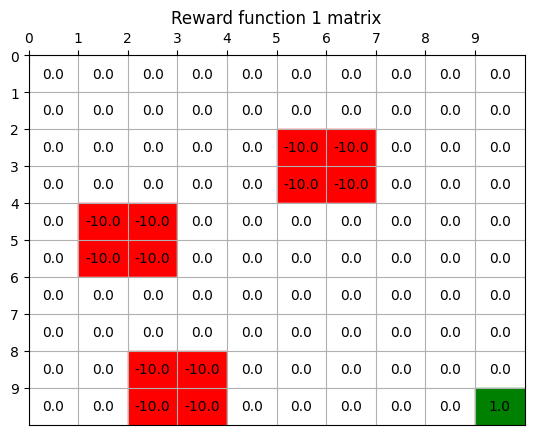

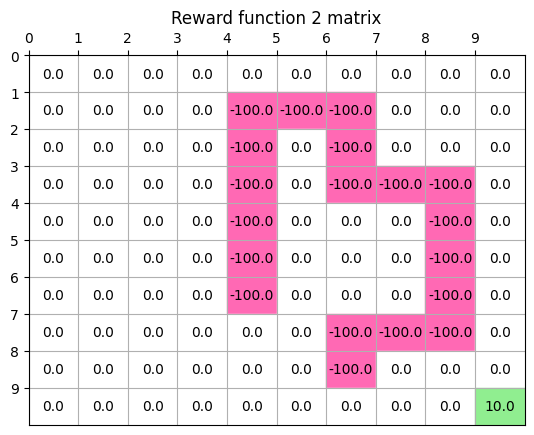

time: 711 ms (started: 2025-08-09 01:30:10 +00:00)


In [ ]:
## Plotting the reward value for each state of the grid

def reward_grid_plot():
    reward_matrix = np.zeros((grid_size, grid_size))
    color_matrix = np.full((grid_size, grid_size), 'white', dtype=object)
    for j in range(grid_size):
        for i in range(grid_size):
            reward_matrix[i][j] = gw.reward(gw.point_to_int((i,j)))
            if reward_matrix[i][j] > 0:
                # green
                color_matrix[i][j] = 'green'
            elif reward_matrix[i][j] < 0:
                # red
                color_matrix[i][j] = 'red'
    plot_matrix(reward_matrix, color_matrix, "Reward function 1 matrix")
    return reward_matrix
reward_matrix = reward_grid_plot()

## Plotting the reward value for each state of the grid

def reward_grid_plot2():
    reward_matrix = np.zeros((grid_size, grid_size))
    color_matrix = np.full((grid_size, grid_size), 'white', dtype=object)
    for j in range(grid_size):
        for i in range(grid_size):
            reward_matrix[i][j] = gw.reward2(gw.point_to_int((i,j)))
            if reward_matrix[i][j] > 0:
                # green
                color_matrix[i][j] = 'lightgreen'
            elif reward_matrix[i][j] < 0:
                # red
                color_matrix[i][j] = 'hotpink'

    plot_matrix(reward_matrix, color_matrix, "Reward function 2 matrix")
    return reward_matrix
reward_matrix2 = reward_grid_plot2()

### Q1:  Heat maps of Reward fn 1 and 2 (10pt)

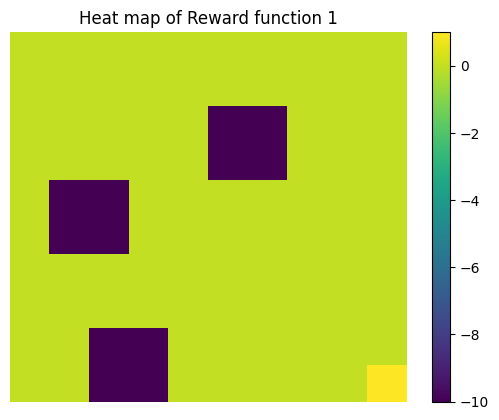

time: 125 ms (started: 2025-08-09 01:30:10 +00:00)


In [ ]:
## For visualization generating the heat map of the ground truth reward

plt.pcolor(np.flipud(reward_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of Reward function 1')
plt.show()

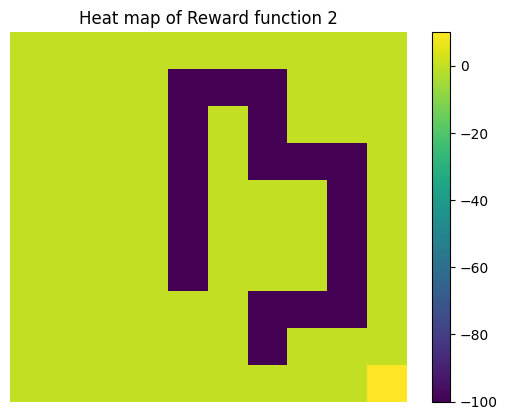

time: 120 ms (started: 2025-08-09 01:30:11 +00:00)


In [ ]:
## For visualization generating the heat map of the ground truth reward

plt.pcolor(np.flipud(reward_matrix2))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of Reward function 2')
plt.show()

## Optimal policy

### Q2. Create the MDP by setting up state-space, action set, transition probabilities, discount factor, and reward function (40 pt)

• Number of states = 100 (state space is a 10 by 10 square grid as displayed in figure 1)
• Number of actions = 4 (set of possible actions is displayed in figure 2)
• w = 0.1
• Discount factor = 0.8
• Reward function 1

In [ ]:
## Implementing the algorithm for computing the optimal value function for each state
## The algorithm takes as input the MDP and returns an array of optimal values,
## where i^th value in the array corresponds to the optimal value of the i^th state.
import math
def optimal_value(n_states, n_actions, transition_probabilities, reward,
                  discount, threshold=1e-2, steps = math.inf):
    """
    Find the optimal value function.

    n_states: Number of states. int.
    n_actions: Number of actions. int.
    transition_probabilities: Function taking (state, action, state) to
        transition probabilities.
    reward: Vector of rewards for each state.
    discount: MDP discount factor. float.
    threshold: Convergence threshold, default 1e-2. float.
    -> Array of values for each state
    """
    # initialization
    V = np.zeros(n_states)
    delta = np.inf
    # Estimation
    N = 0
    while delta > threshold and N < steps:
        delta = 0.0
        for s in range(n_states):  # 100
            v = V[s]
            V[s] = max([sum([np.multiply(transition_probabilities[s][a][s1], (reward[s1] + np.multiply(discount,  V[s1]))) for s1 in range(n_states)]) for a in range(n_actions)])
            delta = max(delta, abs(v - V[s]))
        N += 1
    print("Number of iterations: ", N, 'of steps = ', steps, ", delta = ", delta )
    return V, N


time: 1.59 ms (started: 2025-08-09 01:30:11 +00:00)


Number of iterations:  21 of steps =  inf , delta =  0.00938117320109072


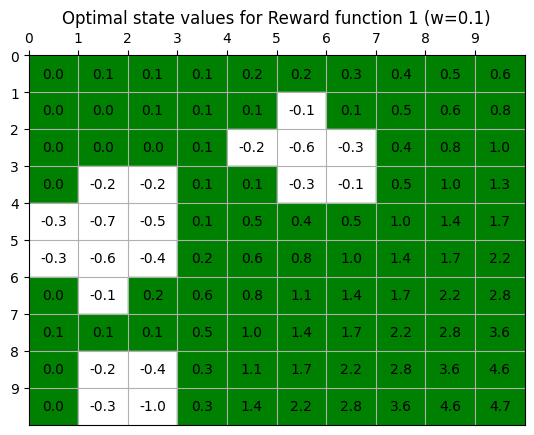

time: 3.4 s (started: 2025-08-09 01:30:11 +00:00)


In [ ]:
## Plotting the optimal values of each state in the grid

# Generating the array of rewards to be passed onto the optimal value algorithm

reward_states = np.zeros(gw.n_states)
for i in range(gw.n_states):
    reward_states[i] = gw.reward(i)

# Computing the optimal value of each state
v, N_star = optimal_value(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount)

# Plotting
color_matrix = np.full((grid_size, grid_size), 'white', dtype=object)
value_matrix = np.zeros((grid_size, grid_size))
for i in range(gw.n_states):
    value_matrix[int(i%grid_size)][int(i/grid_size)] = round(v[i], 1)
    if v[i] > 0:
        color_matrix[int(i%grid_size)][int(i/grid_size)] = 'green'

plot_matrix(value_matrix, color_matrix, "Optimal state values for Reward function 1 (w=0.1)")
V_1_1 =v

Let’s assume that your value iteration algorithm converges in N steps. Plot snapshots of state values in 5 different steps linearly distributed from 1 to N. Report N and your step numbers. What observations do you have from the plots?

Number of iterations:  1 of steps =  1 , delta =  0.9869999990494118


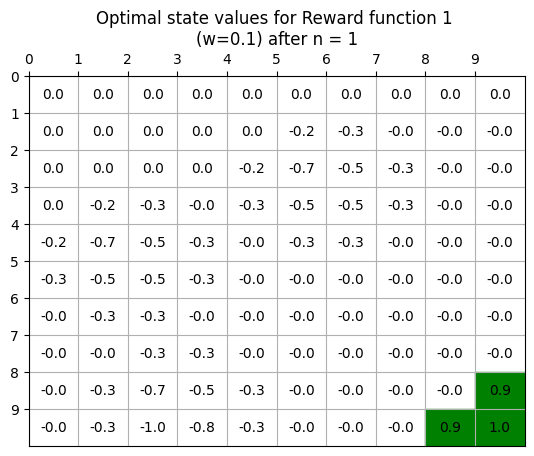

Number of iterations:  6 of steps =  6 , delta =  0.30683879690079463


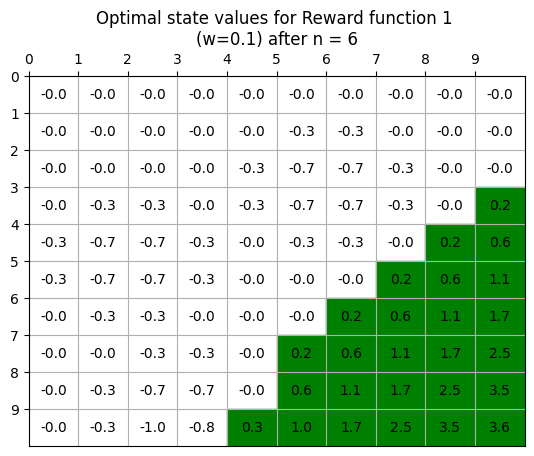

Number of iterations:  11 of steps =  11 , delta =  0.09541618844989497


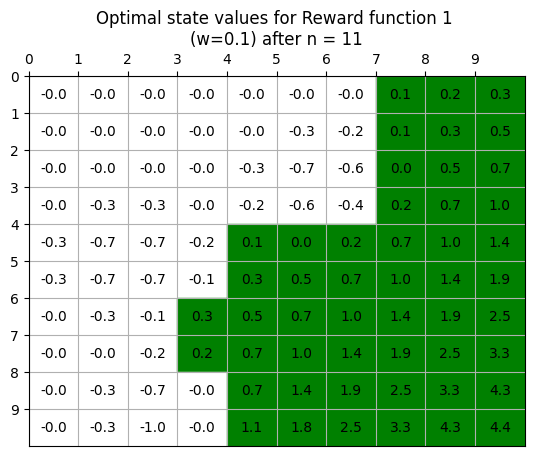

Number of iterations:  16 of steps =  16 , delta =  0.03012379029567519


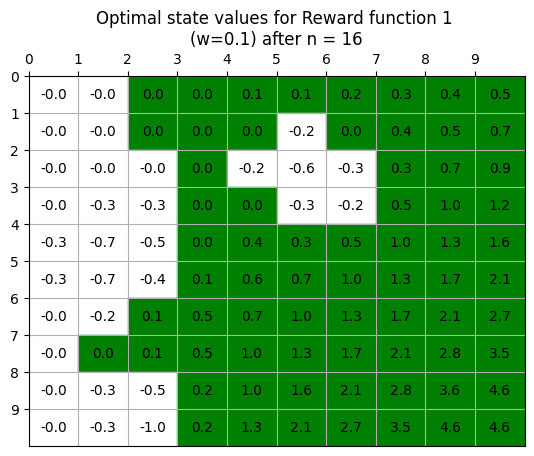

Number of iterations:  21 of steps =  21 , delta =  0.00938117320109072


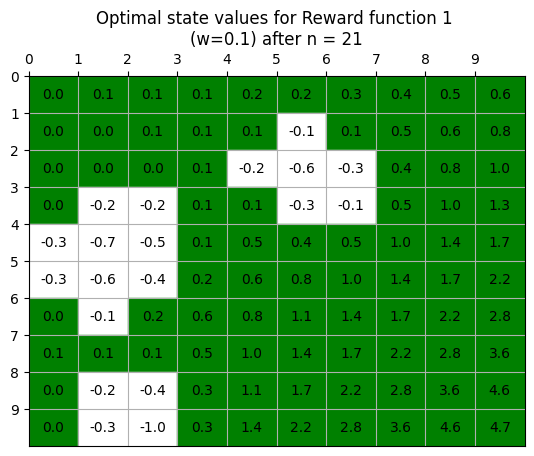

time: 9.53 s (started: 2025-08-09 01:30:14 +00:00)


In [ ]:
# iterate N* in 5 steps
step_vals = np.linspace(1, N_star, 5, dtype=int)
for n in step_vals:
    v, _ = optimal_value(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount, steps=n)

# Plotting
    color_matrix = np.full((grid_size, grid_size), 'white', dtype=object)
    value_matrix_5 = np.zeros((grid_size, grid_size))
    for i in range(gw.n_states):
        value_matrix_5[int(i%grid_size)][int(i/grid_size)] = v[i].round(decimals=1)
        if v[i] > 0:
            color_matrix[int(i%grid_size)][int(i/grid_size)] = 'green'

    plot_matrix(value_matrix_5, color_matrix, "Optimal state values for Reward function 1 \n(w=0.1) after n = " + str(n))


**Answer:** As the number of iterations increases and the number of steps increases, the area of positive optimal state value functions increases in size, covering a larger portion of the grid. This area expands out from the lower right part of the grid. The values of the rewards in each state of the environment also increases as the steps and iterations increase. For example, the reward in the bottom right corner of the grid increases from 0.7 at N=5 to 2.0 at N=17. The state values near the "red" areas in the reward function are also generally low in value.

### Q3. Generate a heat map of the optimal state values across the 2-d grid. (5 pt)

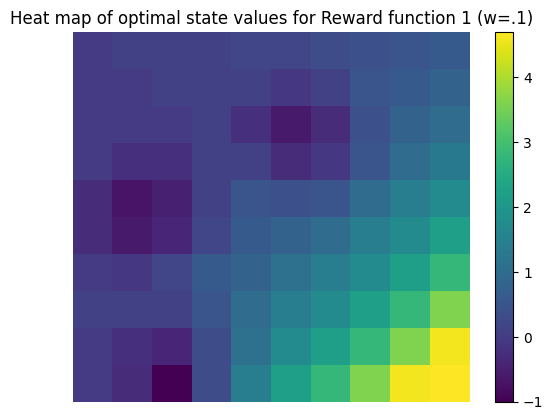

time: 266 ms (started: 2025-08-09 01:30:24 +00:00)


In [ ]:
## For visualization generating the heat map of the optimal state values

plt.pcolor(np.flipud(value_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of optimal state values for Reward function 1 (w=.1)')
plt.show()

### Q4. Explain the distribution of the optimal state values across the 2-D grid. (15 pt)

**Answer:** The most optimal state values for reward function one are found in the lower right side of the heat map above.  This shows that as the agent navigates towards the lower right side of the 2-D grid, they will be given a higher reward. This encourages the agent to prioritize movement towards the lower right area and away from the groupings of negative reward values towards the upper left side of the grid. The heat map shows the gradual change from the 3 local minimum values toward the bottom right corner which is the local maxima.

### Q5. Implement the computation step of the value iteration algorithm. (20 pt)

In [ ]:
## Implementing the function for computing the optimal policy.
## The function takes as input the MDP and outputs a
## deterministic policy, which is an array of actions.
## The i^th entry in the array corresponds to the
## optimal action to take at the i^th state.

def find_policy(n_states, n_actions, transition_probabilities, reward, discount,
                threshold=1e-2, v=None, stochastic=False):
    """
    Find the optimal policy.

    n_states: Number of states. int.
    n_actions: Number of actions. int.
    transition_probabilities: Function taking (state, action, state) to
        transition probabilities.
    reward: Vector of rewards for each state.
    discount: MDP discount factor. float.
    threshold: Convergence threshold, default 1e-2. float.
    v: Value function (if known). Default None.
    stochastic: Whether the policy should be stochastic. Default True.
    -> Action probabilities for each state or action int for each state
        (depending on stochasticity).
    """

    if v is None:
        v, _ = optimal_value(n_states, n_actions, transition_probabilities, reward,
                          discount, threshold)
    def _policy(s):
        return np.argmax([
            sum(transition_probabilities[s][a][s1] * (reward[s1] + discount * v[s1])
            for s1 in range(n_states))
        for a in range(n_actions)])

    if stochastic:
        policy = np.zeros((n_states, n_actions))
        for s in range(n_states):
            policy[s][_policy(s)] = 1
    else:
        policy = np.array([_policy(s) for s in range(n_states)])
    return policy

time: 1.45 ms (started: 2025-08-09 01:30:24 +00:00)


In [ ]:
## Function for plotting the optimal actions at each state in the grid
## The function takes as input the matrix containing optimal actions
## and plots the actions for each state on the grid

def plot_arrow(action_matrix, title="Action", compare_matrix=None):

    fig, ax = plt.subplots()
    num_rows = len(action_matrix)
    min_val, max_val = 0, num_rows

    for i in range(num_rows):
        for j in range(num_rows):
            c = action_matrix[i][j]
            arrow = ''
            if(c == 0):
                arrow = u'↓'
            elif(c == 1):
                arrow = u'→'
            elif(c == 2):
                arrow = u'↑'
            else:
                arrow = u'←'

            ax.text(j + 0.5, i + 0.5, arrow, va='center', ha='center')

            # add this for IRL plots with color
            if compare_matrix is not None:
              if c == compare_matrix[i][j]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color="beige"))
              else:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color="purple"))

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(max_val, min_val)
    ax.set_xticks(np.arange(max_val))
    ax.set_yticks(np.arange(max_val))
    ax.xaxis.tick_top()
    ax.grid()
    plt.title(title)

time: 2.09 ms (started: 2025-08-09 01:30:24 +00:00)


Number of iterations:  21 of steps =  inf , delta =  0.00938117320109072


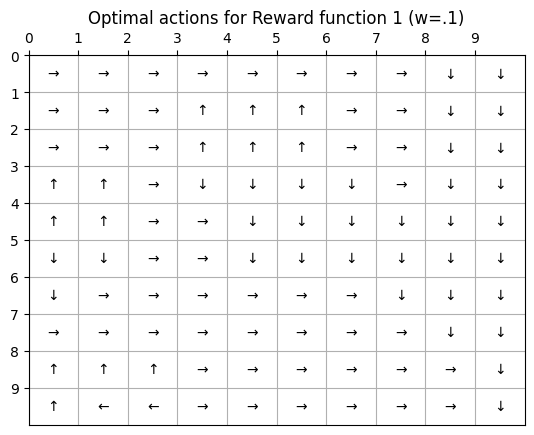

time: 3.11 s (started: 2025-08-09 01:30:24 +00:00)


In [ ]:
## Plotting the optimal actions for each state in the grid

# Finding the array of optimal policy

optimal_policy = find_policy(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount, stochastic=False)

op_q5 = optimal_policy
# Generating the matrix containing the optimal actions

action_matrix = np.zeros((grid_size, grid_size))
for i in range(gw.n_states):
    action_matrix[int(i%grid_size)][int(i/grid_size)] = optimal_policy[i]

# Plotting
plot_arrow(action_matrix, "Optimal actions for Reward function 1 (w=.1)")


**Answer:** Yes, the optimal policy of the agent matches our intuition of moving towards the lower right corner. From the grid above, we can see that the optimal action of the agent in each state of the environment encourages movement of the agent towards the lower right of the grid. The overall trend and direction of the arrows points towards this bottom corner. From observing the previous heat map, we can see that the reward is higher in this lower right corner of the grid, thus we had previously concluded that in order to receive the highest reward, the agent should move towards this area.

It is possible for the agent to compute the optimal action to take at each state. At each state in the grid, the agent can determine the best action to take based on the perceived reward received after taking that action. The perceived reward comes from observing and comparing the optimal values of the neighboring states.

### Q6. Modify the environment by using Reward function 2. Generate a figure with optimal value of each state in the grid. (10 pt)

Number of iterations:  31 of steps =  inf , delta =  0.009390572496691174


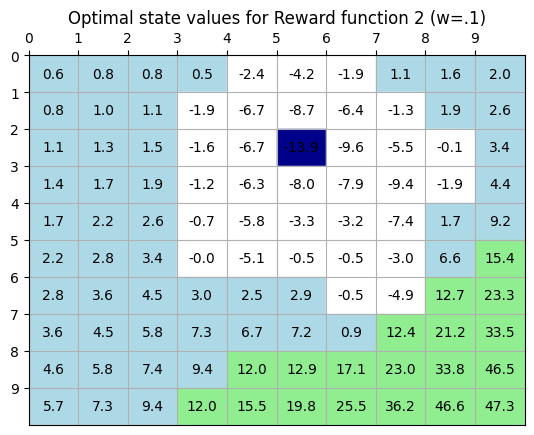

time: 4.42 s (started: 2025-08-09 01:30:27 +00:00)


In [ ]:
## Plotting the optimal values of each state in the grid

# Generating the array of rewards to be passed onto the optimal value algorithm

reward_states = np.zeros(gw.n_states)
for i in range(gw.n_states):
    reward_states[i] = gw.reward2(i)   # use reward function 2
# Computing the optimal value of each state

v, _ = optimal_value(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount)

# Plotting
color_matrix = np.full((grid_size, grid_size), 'white', dtype=object)
value_matrix2 = np.zeros((grid_size, grid_size))
for i in range(gw.n_states):
    value_matrix2[int(i%grid_size)][int(i/grid_size)] = round(v[i], 1)
    if v[i] > 10:
        color_matrix[int(i%grid_size)][int(i/grid_size)] = 'lightgreen'
    elif v[i] > 0:
        color_matrix[int(i%grid_size)][int(i/grid_size)] = 'lightblue'
    elif v[i] < -10:
        color_matrix[int(i%grid_size)][int(i/grid_size)] = 'darkblue'

plot_matrix(value_matrix2, color_matrix, "Optimal state values for Reward function 2 (w=.1)")
V_2_1 = v

### Q7. Generate a heat map of the optimal state values using reward function 2. (20 pt)

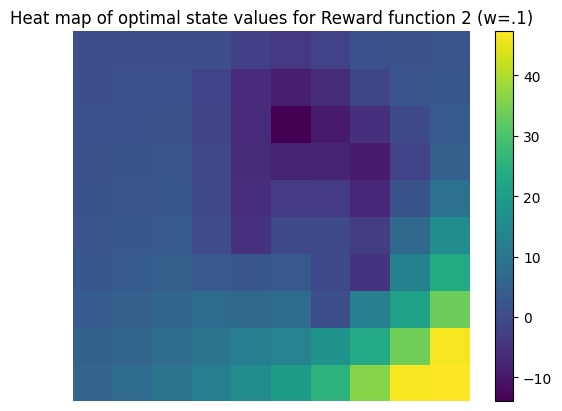

time: 118 ms (started: 2025-08-09 01:30:31 +00:00)


In [ ]:
## For visualization generating the heat map of the optimal state values

plt.pcolor(np.flipud(value_matrix2))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of optimal state values for Reward function 2 (w=.1)')
plt.show()

Explain the distribution of the optimal state values across the 2D grid

**Answer**: Similar to the previous heat map for reward function one, the heat map of reward function two also shows the higher optimal state values in the lower right hand corner. Thus the agent is encouraged to move towards the lower right of the 2-D grid. Unlike the previous heat map, there is a smaller area in the upper middle of the map where the reward is negative. The map generally shows positive to neutral rewards, but the upper right contains lower rewards, which reflects the "red" areas in reward function 2, discouraging the agent from moving to that area. The heat map shows the gradual change from the local minimum value in the box 52 toward the bottom right corner which is the local maxima. The optimal values of reward function 2 ranges from -14 to 47.

### Q8. Implement the computation step of the value iteration algorithm and generate a figure for reward function 2 with arrows (20 pt)

Number of iterations:  31 of steps =  inf , delta =  0.009390572496691174


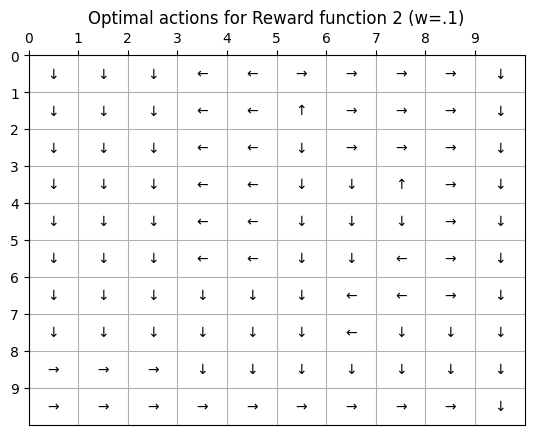

time: 4.42 s (started: 2025-08-09 01:30:32 +00:00)


In [ ]:
## Plotting the optimal actions for each state in the grid

# Finding the array of optimal policy

optimal_policy = find_policy(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount, stochastic=False)

op_q8 = optimal_policy

# Generating the matrix containing the optimal actions

action_matrix2 = np.zeros((grid_size, grid_size))
for i in range(gw.n_states):
    action_matrix2[int(i%grid_size)][int(i/grid_size)] = optimal_policy[i]

# Plotting
plot_arrow(action_matrix2, "Optimal actions for Reward function 2 (w=.1)")


**Answer:** Yes, the optimal policy does match our intuition that the agent should take actions to move towards the lower right of the grid. As seen in the grid above, the general direction of the arrows points towards the lower right hand corner, (evident in the last row and last column) the area that we previously determined to have the greatest state value reward.

### Q9. Change the hyperparameter w to 0.6 and find the optimal policy map for both reward functions. (20 pt)

In [ ]:
def process_gridworld(gw, reward_states, rf, compare_matrix=None):
    v, _ = optimal_value(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount)

    # Plotting
    color_matrix = np.full((grid_size, grid_size), 'white', dtype=object)
    value_matrix = np.zeros((grid_size, grid_size))
    for i in range(gw.n_states):
        value_matrix[int(i%grid_size)][int(i/grid_size)] = round(v[i], 1)
        if v[i] > 0:
            color_matrix[int(i%grid_size)][int(i/grid_size)] = 'green'

    plot_matrix(value_matrix, color_matrix, f"Optimal state values for Reward function {rf} (w={gw.wind})")
    plt.pcolor(np.flipud(value_matrix))
    plt.colorbar()
    plt.axis('off')
    plt.title(f'Heat map of optimal state values for Reward function {rf} (w={gw.wind})')
    plt.show()

    optimal_policy = find_policy(gw.n_states, gw.n_actions, gw.transition_probability, reward_states, gw.discount, stochastic=False)

    # Generating the matrix containing the optimal actions
    action_matrix = np.zeros((grid_size, grid_size))
    for i in range(gw.n_states):
        action_matrix[int(i%grid_size)][int(i/grid_size)] = optimal_policy[i]

    # Plotting
    plot_arrow(action_matrix, f"Optimal actions for Reward function {rf} (w={gw.wind})", compare_matrix)
    return v


time: 1.2 ms (started: 2025-08-08 10:32:55 +00:00)


Number of iterations:  16 of steps =  inf , delta =  0.007677766638519934


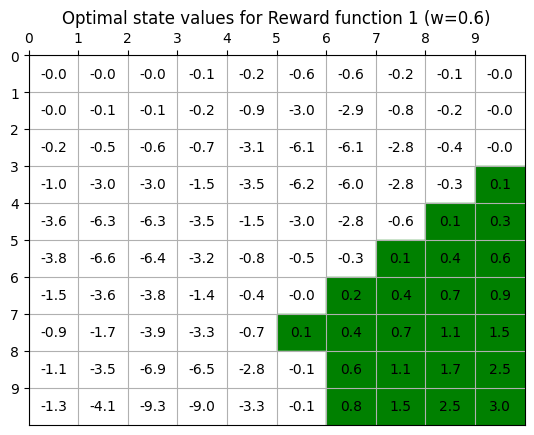

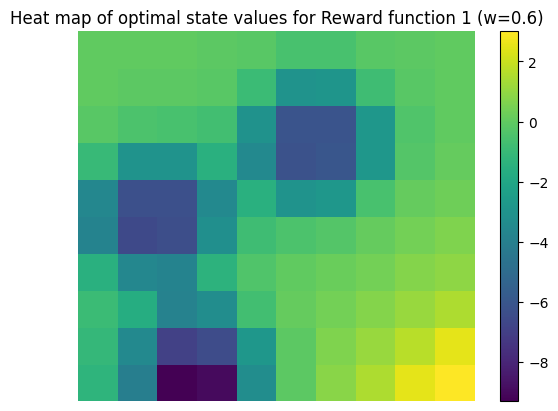

Number of iterations:  16 of steps =  inf , delta =  0.007677766638519934
Number of iterations:  22 of steps =  inf , delta =  0.00814523984101001


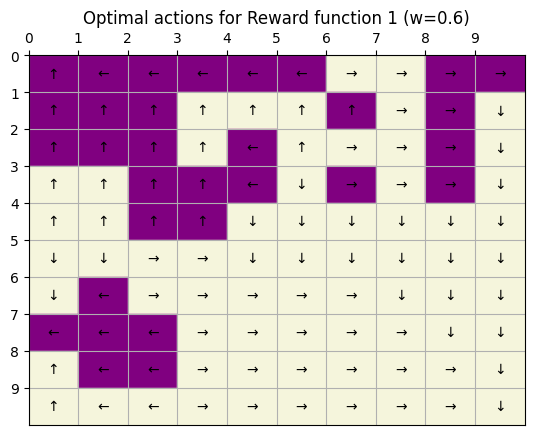

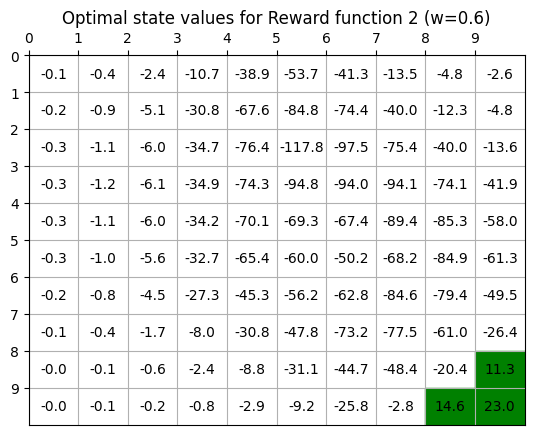

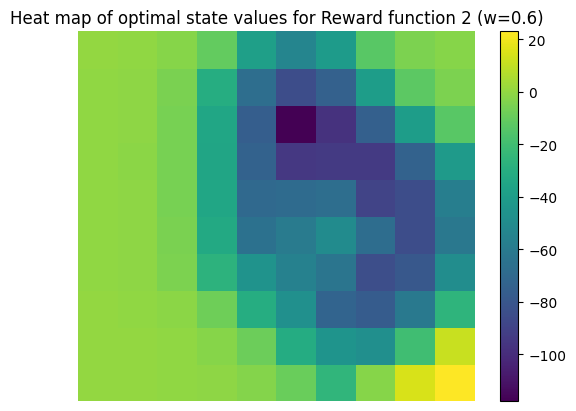

Number of iterations:  22 of steps =  inf , delta =  0.00814523984101001


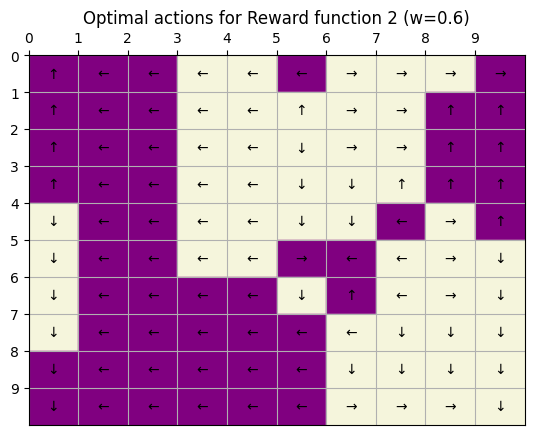

time: 10.2 s (started: 2025-08-08 10:32:55 +00:00)


In [ ]:
## Creating the gridworld MDP with the following parameters
grid_size = 10
wind = 0.6
discount = 0.8

# Make the gridworld and associated data.
gw = Gridworld(grid_size, wind, discount)

######################## Reward fn 1 ########################
## Plotting the optimal values of each state in the grid
# Generating the array of rewards to be passed onto the optimal value algorithm
reward_states = np.zeros(gw.n_states)
for i in range(gw.n_states):
    reward_states[i] = gw.reward(i)

V_1_6 = process_gridworld(gw, reward_states, 1, action_matrix)
######################## Reward fn 2 ########################
## Plotting the optimal values of each state in the grid
# Generating the array of rewards to be passed onto the optimal value algorithm
reward_states2 = np.zeros(gw.n_states)
for i in range(gw.n_states):
    reward_states2[i] = gw.reward2(i)

V_2_6 = process_gridworld(gw, reward_states2, 2, action_matrix2)



Explain the differences you observe. What do you think about value of new w compared to previous value? Choose the 2 that you think give rise to better optimal policy and use that w for the next states of the project.

__Answer:__ From slide 30,
a policy ($\pi$) is defined to be better than or equal to a policy ($\pi\prime$) if its expected return is greater than or equal to that of $\pi\prime$ for all states.

$ \pi \geq \pi\prime  <=> V^\pi (s) \geq V^{\pi\prime} (s) $

Reward function one: As seen in the optimal actions grid above, for reward function one, the actor is encouraged to move towards the outer edges of the grid, not only towards the lower right of the grid. In the first optimal actions grid for reward function one, from question 5, the actor is generally encouraged to move towards the lower right. After changing w to 0.6, there is a larger area of optimal values across the grid and especially towards the outer perimeter, so the actor is not only directed towards the lower right corner.

Reward function two: Compared to the first optimal actions grid for reward function two, the above grid of does not show a general trend towards the lower right hand corner. This is due to there being a large area around the outer perimeter of the grid that has a perceived optimal reward. The actor is encouraged to move towards any of these optimal areas, towards any of the edges of the grid, not just those in the lower right corner.

w = 0.6: As the w value increases from 0.1. and 0.6, the general optimal values for the reward functions decreases, but the range of optimal values gets larger. Thus, the actor is more encouraged to move away from the lowest optimal value states rather than move towards the highest optimal value states located at the lower right corner of the grid. Per the optimal action grids above, as the w value increases, the actor is encouraged to move towards the edges rather than only towards the lower right. In order to outline a more directed and specific path for the actor, a lower w is better and more optimal.

In [ ]:
# compare state values for reward function 1 between w=.1 and w=.6
if (V_1_1 > V_1_6).all():
    print("w = 0.1 is better for reward function 1.")
else:
    print("w = 0.6 is better for reward function 1.")
# compare state values for reward function 2 between w=.1 and w=.6
if (V_2_1 > V_2_6).all():
    print("w = 0.1 is better for reward function 2.")
else:
    print("w = 0.6 is better for reward function 2.")

w = 0.1 is better for reward function 1.
w = 0.1 is better for reward function 2.
time: 1.01 ms (started: 2025-08-08 10:33:05 +00:00)


w = 0.1 will be used for the below project.

## B. Inverse Reinforcement Learning (240 pt)

### Q10. Express c, x, D, b (10 pt)

Express c, x, D, b in terms of R, $P_a$, $P_{a1}$, $t_i$, u, $\lambda$ and $R_{max}$.

* $P_a$ = transition_probability for action a
* $P_{a1}$ = transition_probability from expert
* $t_i$ = optimization variable
* u = optimization variable for action
* $\lambda$ = adjustable penalty coefficient
* $R_{max}$ = maximum reward
* reference: https://ai.stanford.edu/~ang/papers/icml00-irl.pdf
* reference: https://www.youtube.com/watch?v=_EgoDT7RHwE

$$[(P_{a1}(i) - P_a(i))(I - γP_{a1})^{-1}R] ≥ t_i, ∀a ∈ A \backslash a_1, ∀i$$
$$(P_{a1} - P_a)(I - γP_{a1})^{-1}R ⪰ 0, ∀a ∈ A \backslash a_1$$
$$-u ⪯ R ⪯ u$$
$$|R_i| ≤ R_{max}, i = 1, 2, · · · , |S|$$


**Answer:**

c = $\begin{bmatrix} 1_{|S|}\\-\lambda_{|S|}\\0_{|S|}\end{bmatrix}   ∈ \mathbb{R}^{3|S|} $

x = $\begin{bmatrix} t\\u\\R\end{bmatrix}∈ \mathbb{R}^{3|S|} $

D = $\begin{bmatrix}
I_{|S|.(A-1)*|S|} & 0 & {-[(P_{a1}(i) - P_a(i))(I - γP_{a1})^{-1}]} \\
0 & 0 & {-[(P_{a1} - P_a)(I - γP_{a1})^{-1}]} \\
0 & -I_{|S|*|S|} & I_{|S|*|S|} \\
0 & -I_{|S|*|S|} & -I_{|S|*|S|} \\
0 & 0 & I_{|S|*|S|} \\
0 & 0 & -I_{|S|*|S|} \\
\end{bmatrix}   ∈ \mathbb{R}^{(2|S|(A-1)+4|S|) * 3|S|} $

b = $\begin{bmatrix}
0_{|S|.(A-1)} \\
0_{|S|.(A-1)}  \\
0_{|S|} \\
0_{|S|} \\
R_{max |S|} \\
R_{max |S|}\\
\end{bmatrix}  ∈ \mathbb{R}^{(2|S|(A-1)+4|S|)}$


use γ = 0.9

In [ ]:
!pip install cvxopt
## IRL algorithm
## LP formulation
# https://github.com/MatthewJA/Inverse-Reinforcement-Learning/blob/master/irl/linear_irl.py

from cvxopt import matrix, solvers
solvers.options.update({
    'abstol': 1e-7,
    'reltol': 1e-6,
    'feastol': 1e-7,
    'show_progress': False,
    'maxiters': 500})

def irl(n_states, n_actions, transition_probability, policy, discount, Rmax,
        l1):
    """
    Find a reward function with inverse RL as described in Ng & Russell, 2000.

    n_states: Number of states. int.
    n_actions: Number of actions. int.
    transition_probability: NumPy array mapping (state_i, action, state_k) to
        the probability of transitioning from state_i to state_k under action.
        Shape (N, A, N).
    policy: Vector mapping state ints to action ints. Shape (N,).
    discount: Discount factor. float.
    Rmax: Maximum reward. float.
    l1: l1 regularisation. float.
    -> Reward vector
    """

    A = set(range(n_actions))  # Set of actions to help manage reordering
                               # actions.
    # The transition policy convention is different here to the rest of the code
    # for legacy reasons; here, we reorder axes to fix this. We expect the
    # new probabilities to be of the shape (A, N, N).
    transition_probability = np.transpose(transition_probability, (1, 0, 2))
    #print (A, transition_probability.shape)

    P_pi = np.zeros((n_states, n_states))
    for s in range(n_states):
        P_pi[s, :] = transition_probability[policy[s], s, :]
    F = np.linalg.inv(np.eye(n_states) - discount * P_pi)

    def T(a, s):
        # (P_pi(s,:) - P_a(s,:)) F
        x = transition_probability[policy[s], s, :] - transition_probability[a, s, :]
        return x.dot(F)

    # This entire function just computes the block matrices used for the LP
    # formulation of IRL.

    # Maximize c^T . x ==> minimize -c^T . x

    ##WRITE CODE HERE
    c = np.concatenate([
            np.ones(n_states),     # t
            -l1*np.ones(n_states), # u
            np.zeros(n_states)     # R
        ])

    # construct D matrix row by row
    T_stack = [-T(a, s) for s in range(n_states) for a in A - {policy[s]}]
    T_row = np.array(T_stack).shape[0]

    ######### Changes Here##############
    S = np.zeros((T_row, n_states))
    idx = 0
    for s in range(n_states):
        for a in A - {policy[s]}:
            S[idx, s] = 1.0
            idx += 1
    ######### Changes Finished##############

    D1 = np.hstack([
        S,
        np.zeros((T_row, n_states)),
        np.array(T_stack)
    ])
    D2 = np.hstack([
        np.zeros((T_row, n_states)),
        np.zeros((T_row, n_states)),
        np.array(T_stack)
    ])
    D3= np.hstack([
        np.zeros((n_states, n_states)),
        -np.eye(n_states),
        np.eye(n_states)
    ])
    D4= np.hstack([
        np.zeros((n_states, n_states)),
        -np.eye(n_states),
        -np.eye(n_states)
    ])
    D5= np.hstack([
        np.zeros((n_states, n_states)),
        np.zeros((n_states, n_states)),
        np.eye(n_states)
    ])
    D6= np.hstack([
        np.zeros((n_states, n_states)),
        np.zeros((n_states, n_states)),
        -np.eye(n_states)
    ])

    D = np.vstack([D1, D2, D3, D4, D5, D6])

    b = np.concatenate([np.zeros(n_states * (n_actions - 1)), # 1st constraint
            np.zeros(n_states * (n_actions - 1)),  # 2nd constraint
            np.zeros(n_states),    # R-u <= 0
            np.zeros(n_states),    # -R-u <= 0
            Rmax * np.ones(n_states),  # |R| < Rmax
            Rmax * np.ones(n_states)])  # |R| < Rmax

    # expected shapes of c, D, b: (300,), (1000, 300), (1000,)]
    # https://cvxopt.org/examples/tutorial/lp.html
    # https://cvxopt.org/userguide/coneprog.html#linear-programming

    sol = solvers.lp(-matrix(c), matrix(D), matrix(b))
    result = np.array(sol['x'][-n_states:]).flatten()  #(100,) reward vector is the last 100 elements of x
    return np.clip(result, -Rmax, Rmax)

time: 4.13 s (started: 2025-08-08 10:33:05 +00:00)


### Q11: Plot λ (x-axis) against Accuracy (y-axis) (30 pt)

Sweep λ from 0 to 5 to get 500 evenly spaced values for λ. For each value of λ compute OA(s) by following the process described above. For this problem, use the optimal policy of the agent found in question 5 to fill in the OE(s)
 values. Then use equation 3 to compute the accuracy of the IRL algorithm for this value of λ. You need to repeat the above process for all 500 values of λ to get 500 data
 points.

In [ ]:
def accuracy(exp_pol,ag_pol):
  # equation 3
  return np.mean(np.array(exp_pol) == np.array(ag_pol))

def iter_acc(grid_obj,op_pol,op_pol_compare):
    n_states = grid_obj.n_states
    n_actions = grid_obj.n_actions
    tr_prob = grid_obj.transition_probability
    disc = grid_obj.discount
    reward_states = np.zeros(n_states)

    for i in range(n_states):
        reward_states[i] = grid_obj.reward(i)
    Rmax = np.max(np.abs(reward_states))
    accuracy_array = []
    lam_range = np.linspace(0,5,500)
    best_acc = 0
    best_pol = None
    for lam in lam_range:
        # get reward
        print (lam, Rmax)
        reward = irl(n_states, n_actions, tr_prob, op_pol, disc, Rmax, lam)
        # get policy
        if reward is not None:
          ag_pol = find_policy(n_states, n_actions, tr_prob, reward, disc)
          acc = accuracy(op_pol_compare,ag_pol)
          accuracy_array.append(acc)
          if acc > best_acc:
            best_pol = ag_pol
            best_acc = acc
        else:
          accuracy_array.append(0)
    return lam_range, accuracy_array, best_pol, best_acc


time: 1.43 ms (started: 2025-08-08 10:33:09 +00:00)


In [ ]:
#Plotting the accuracy
gw_1 = Gridworld(10, 0.1, 0.9)

reward_states = np.zeros(gw_1.n_states)
for i in range(gw_1.n_states):
    reward_states[i] = gw_1.reward(i)

# compare to q5 policy
optimal_policy_irl1 = find_policy(gw_1.n_states, gw_1.n_actions, gw_1.transition_probability,
                             reward_states, gw_1.discount, stochastic=False)

lam_range, accuracy_array, _, _ = iter_acc(gw_1, optimal_policy_irl1, op_q5)

Number of iterations:  43 of steps =  inf , delta =  0.00966809388844947
0.0 10.0
Number of iterations:  45 of steps =  inf , delta =  0.008742577658944484
0.01002004008016032 10.0
Number of iterations:  45 of steps =  inf , delta =  0.009507226558600479
0.02004008016032064 10.0
Number of iterations:  45 of steps =  inf , delta =  0.009507226860607787
0.03006012024048096 10.0
Number of iterations:  45 of steps =  inf , delta =  0.008986683328899403
0.04008016032064128 10.0
Number of iterations:  51 of steps =  inf , delta =  0.009653478295447826
0.0501002004008016 10.0
Number of iterations:  51 of steps =  inf , delta =  0.00965072399885969
0.06012024048096192 10.0
Number of iterations:  51 of steps =  inf , delta =  0.009650722808714818
0.07014028056112225 10.0
Number of iterations:  51 of steps =  inf , delta =  0.009650724617614515
0.08016032064128256 10.0
Number of iterations:  51 of steps =  inf , delta =  0.009644302744362676
0.09018036072144288 10.0
Number of iterations:  51 of 

In [ ]:
idx = np.argmax(accuracy_array)
best_lambda = lam_range[idx]

time: 1.04 ms (started: 2025-08-08 11:04:20 +00:00)


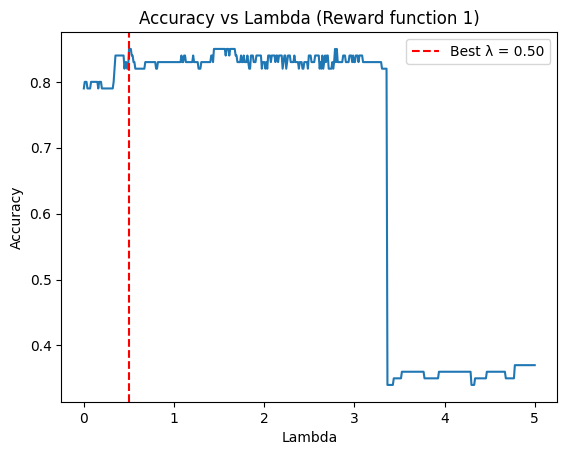

time: 122 ms (started: 2025-08-08 11:04:20 +00:00)


In [ ]:
plt.plot(lam_range, accuracy_array)
plt.axvline(x=best_lambda, color='red', linestyle='--', label=f'Best λ = {best_lambda:.2f}')
plt.xlabel('Lambda')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Lambda (Reward function 1)')
plt.legend()
plt.show()

### Q12. Find λ
λ_max from Q11 (5 pt)

In [ ]:
print(f"λ_max_1 Q11: {best_lambda}, with accuracy: {np.max(accuracy_array):.2f}")

λ_max_1 Q11: 0.501002004008016, with accuracy: 0.85
time: 754 µs (started: 2025-08-08 11:04:20 +00:00)


**Answer**: The lambda_max for reward function 1 is 0.5 and it produced an accuracy of 85%.

### Q13. Generate heat maps of ground truth reward and extracted reward using reward fn 1. (15 pt)

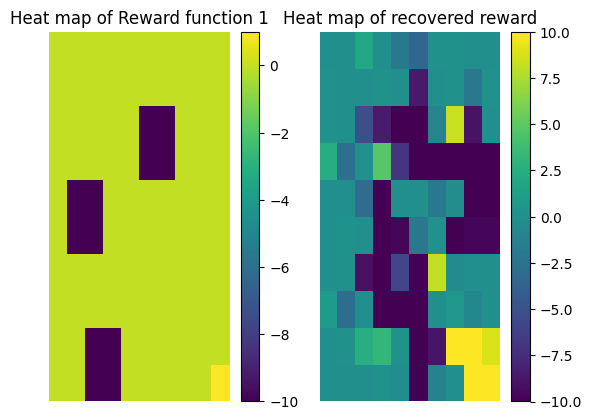

time: 464 ms (started: 2025-08-08 11:04:20 +00:00)


In [ ]:
gw = Gridworld(10, 0.1, 0.9)

n_states = gw.n_states
n_actions = gw.n_actions
tr_prob = gw.transition_probability
disc = gw.discount
Rmax = np.max(np.abs(reward_matrix))
lamda = best_lambda.round(2)

rec_reward = irl(n_states, n_actions, tr_prob, optimal_policy_irl1, disc, Rmax, lamda)
# Creating the recovered reward matrix
rec_reward_matrix = rec_reward.reshape((10, 10))

# ground truth from Q2
plt.subplot(1, 2, 1)
plt.pcolor(np.flipud(reward_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of Reward function 1')

plt.subplot(1, 2, 2)
plt.pcolor(np.flipud(rec_reward_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of recovered reward')
plt.show()

### Q14. compute the optimal values of the states in 2D grid. (10 pt)

Number of iterations:  51 of steps =  inf , delta =  0.00930302349662071


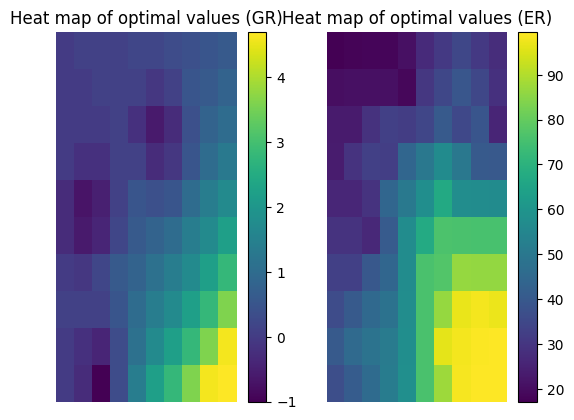

time: 6.07 s (started: 2025-08-08 11:04:21 +00:00)


In [ ]:
## Computing the optimal values of each state with extracted reward vector

opt_val_rec, _ = optimal_value(gw.n_states, gw.n_actions, gw.transition_probability, rec_reward, gw.discount)
# Creating the recovered optimal value matrix
opt_val_rec_matrix = opt_val_rec.reshape((10, 10))

# Generating the heatmap of the optimal values using extracted reward and the groundtruth reward
# ground truth
plt.subplot(1, 2, 1)
plt.pcolor(np.flipud(value_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of optimal values (GR)')

plt.subplot(1, 2, 2)
plt.pcolor(np.flipud(opt_val_rec_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of optimal values (ER)')
plt.show()

### Q15. Compare the heat maps of Q3 and Q14 and provide a brief explanation on their similarities and differences. (10 pt)

**Answer:** Both heat maps show the highest optimal values in the lower right hand corner of the grid. However, there is a larger area of high optimal values in the Q14 (right side) heat map.

Q3 and Q14 are also visualized on different scales. The Q3 heat map shows optimal values between -1 and approximately 4 while the Q14 map shows optimal values between 20 and approximately 90.

Lastly, Q3 has 3 small patches scattered in the map where optimal values are low, which reflects the placement of negative rewards in reward function 1, while the low values in Q14 are all in the upper left corner.

### Q16. Compute the optimal policy of the agent (10 pt)

Number of iterations:  51 of steps =  inf , delta =  0.00930302349662071


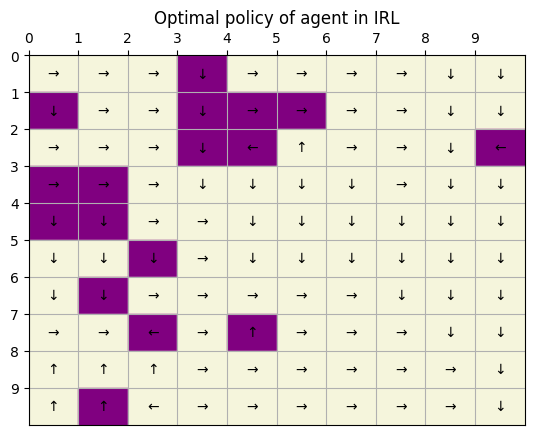

time: 5.52 s (started: 2025-08-08 11:04:27 +00:00)


In [ ]:
## Plotting the optimal policy of the agent

optimal_policy_ag = find_policy(gw.n_states, gw.n_actions, gw.transition_probability, rec_reward, gw.discount, stochastic=False)

# Generating the matrix containing the optimal actions for the agent

action_matrix_ag = np.zeros((grid_size, grid_size))
for i in range(gw.n_states):
    action_matrix_ag[int(i%grid_size)][int(i/grid_size)] = optimal_policy_ag[i]

# Plotting
plot_arrow(action_matrix_ag, "Optimal policy of agent in IRL", action_matrix)


### Q17. Compare the figures of Q5 and Q16 and provide a brief explanation on their similarities and differences. (10 pt)

**Answer:** Both show the trend of moving toward the bottom right corner which is the expected pattern. The majority of the optimal policy above is identical between Q5 and Q16. In both policies, the actor is moving towards the lower right corner of the grid. We color coordinated the actions that are identical and those that differ:

Beige blocks - same as ground truth

Purple blocks - different

With 17 purple blocks, the accuracy is 83% for the extracted reward policy.
Majority of the "incorrect" actions are close to the local minimas and far away from the local maxima.

### Q18. Plot λ (x-axis) against Accuracy (y-axis) using 500 values for λ. (30 pt)

In [ ]:
def iter_acc2(grid_obj,op_pol,op_pol_compare):

    n_states = grid_obj.n_states
    n_actions = grid_obj.n_actions
    tr_prob = grid_obj.transition_probability
    disc = grid_obj.discount
    reward_states = np.zeros(n_states)
    for i in range(n_states):
        reward_states[i] = grid_obj.reward2(i)
    Rmax = max(abs(reward_states))
    accuracy_array = []
    lam_range = np.linspace(0,5,500)
    best_acc = 0

    for lam in lam_range:
        # get reward
        print (lam, Rmax)
        reward = irl(n_states, n_actions, tr_prob, op_pol, disc, Rmax, lam)
        # get policy
        if reward is not None:
          ag_pol = find_policy(n_states, n_actions, tr_prob, reward, disc)
          acc = accuracy(op_pol_compare,ag_pol)
          accuracy_array.append(acc)
          if acc > best_acc:
            best_pol = ag_pol
            best_acc = acc
        else:
          accuracy_array.append(0)
    return lam_range, accuracy_array, best_pol, best_acc


time: 957 µs (started: 2025-08-08 11:04:32 +00:00)


In [ ]:
#Plotting the accuracy
gw_irl_2 = Gridworld(10, 0.1, 0.9)

reward_states2 = np.zeros(gw_irl_2.n_states)
for i in range(gw_irl_2.n_states):
    reward_states2[i] = gw_irl_2.reward2(i)

# compare to q8 policy
optimal_policy2 = find_policy(gw_irl_2.n_states, gw_irl_2.n_actions,
                             gw_irl_2.transition_probability, reward_states2,
                             gw_irl_2.discount, stochastic=False)

lam_range, accuracy_array, _, _ = iter_acc2(gw_irl_2, optimal_policy2, op_q8)

Number of iterations:  64 of steps =  inf , delta =  0.009492846028836155
0.0 100.0
Number of iterations:  51 of steps =  inf , delta =  0.009042225110761137
0.01002004008016032 100.0
Number of iterations:  51 of steps =  inf , delta =  0.00904466490305822
0.02004008016032064 100.0
Number of iterations:  51 of steps =  inf , delta =  0.009078268658640809
0.03006012024048096 100.0
Number of iterations:  51 of steps =  inf , delta =  0.009001952836115379
0.04008016032064128 100.0
Number of iterations:  51 of steps =  inf , delta =  0.009002775703379484
0.0501002004008016 100.0
Number of iterations:  51 of steps =  inf , delta =  0.009002770996062281
0.06012024048096192 100.0
Number of iterations:  51 of steps =  inf , delta =  0.009002714204598306
0.07014028056112225 100.0
Number of iterations:  52 of steps =  inf , delta =  0.008184065549755815
0.08016032064128256 100.0
Number of iterations:  52 of steps =  inf , delta =  0.00820837437015598
0.09018036072144288 100.0
Number of iteration

In [ ]:
idx_2 = np.argmax(accuracy_array)
best_lambda_2 = lam_range[idx_2]

time: 657 µs (started: 2025-08-08 11:37:24 +00:00)


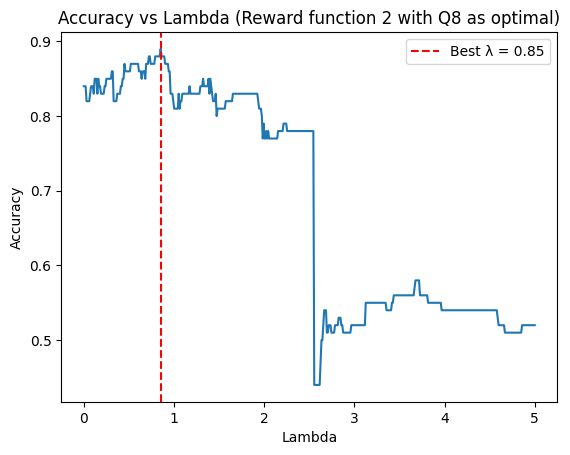

time: 117 ms (started: 2025-08-08 11:37:24 +00:00)


In [ ]:
plt.plot(lam_range, accuracy_array)
plt.axvline(x=best_lambda_2, color='red', linestyle='--', label=f'Best λ = {best_lambda_2:.2f}')
plt.xlabel('Lambda')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Lambda (Reward function 2 with Q8 as optimal)')
plt.legend()
plt.show()

### Q19. Use the plot in Q18 to compute the value of λ_max (5 pt)

In [ ]:
print(f"λ_max Q18: {best_lambda_2}, with accuracy of {np.max(accuracy_array):.2f}")

λ_max Q18: 0.8517034068136272, with accuracy of 0.89
time: 967 µs (started: 2025-08-08 11:37:24 +00:00)


**Answer:** The lambda_max for reward function 2 is found to be 0.85 with an accuracy of 89%.

### Q20. Generate heat maps of ground truth reward and the extracted reward using reward fn 2 (15 pt)

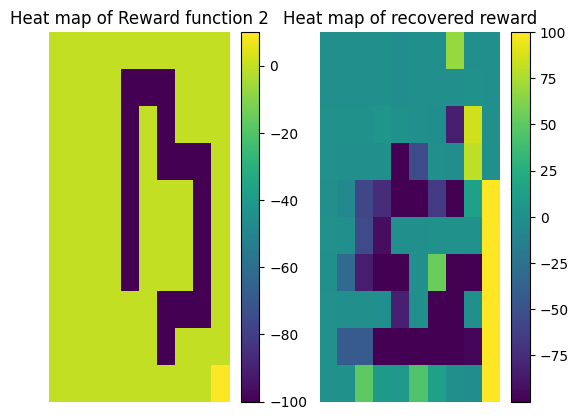

time: 471 ms (started: 2025-08-08 11:37:24 +00:00)


In [ ]:
gw_irl_2 = Gridworld(10, 0.1, 0.9)

n_states = gw_irl_2.n_states
n_actions = gw_irl_2.n_actions
tr_prob = gw_irl_2.transition_probability
disc = gw_irl_2.discount
Rmax = np.max(np.abs(reward_matrix2))
lamda = best_lambda_2.round(2)

rec_reward2 = irl(n_states, n_actions, tr_prob, optimal_policy2, disc, Rmax, lamda)
# Creating the recovered reward matrix
rec_reward_matrix2 = rec_reward2.reshape((10, 10))

plt.subplot(1, 2, 1)
plt.pcolor(np.flipud(reward_matrix2))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of Reward function 2')

plt.subplot(1, 2, 2)
plt.pcolor(np.flipud(rec_reward_matrix2))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of recovered reward')
plt.show()

### Q21.  Compute the optimal values of the states in the 2D grid. (10 pt)

Number of iterations:  70 of steps =  inf , delta =  0.009458347423219493


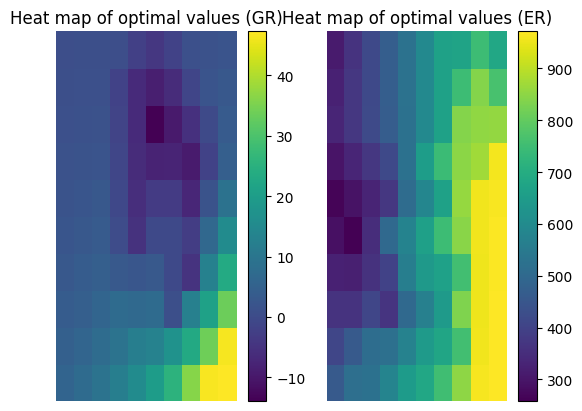

time: 7.03 s (started: 2025-08-08 11:37:24 +00:00)


In [ ]:
## Computing the optimal values of each state with extracted reward vector

opt_val_rec2, _ = optimal_value(gw_irl_2.n_states, gw_irl_2.n_actions,
                                gw_irl_2.transition_probability, rec_reward2,
                                gw_irl_2.discount)
# Creating the recovered optimal value matrix
opt_val_rec_matrix = opt_val_rec2.reshape((10, 10))

# Generating the heatmap of the optimal values using extracted reward and the groundtruth reward

plt.subplot(1, 2, 1)
plt.pcolor(np.flipud(value_matrix2))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of optimal values (GR)')

plt.subplot(1, 2, 2)
plt.pcolor(np.flipud(opt_val_rec_matrix))
plt.colorbar()
plt.axis('off')
plt.title('Heat map of optimal values (ER)')
plt.show()

### Q22. Compare the heat maps of Q7 and Q21 and provide a brief explanation on their similarities and differences. (10 pt)

**Answer:** Both the Q7 and Q21 heat maps show the optimal values in the lower right hand corner of the grid. However, the Q21 map has a larger area of optimal values that climb up the right side of the map. Thus, the optimal values for Q21 encourage the actor to move to the right side of the grid rather than specifically to the lower right corner like in Q3.

Q3 and Q21 are also on different scales. Q3 contains optimal values between approximately -10 and 40 while Q21 contains higher values between approximately 300 and 900.

Q3 also shows one patch of the lowest optimal values in the middle of the map, which reflects the placement of negative rewards in reward function 2, while the lowest optimal values of Q21 are concentrated on the left side of the map.

### Q23. Compute the optimal policy of the agent. (10 pt)

Number of iterations:  70 of steps =  inf , delta =  0.009458347423219493


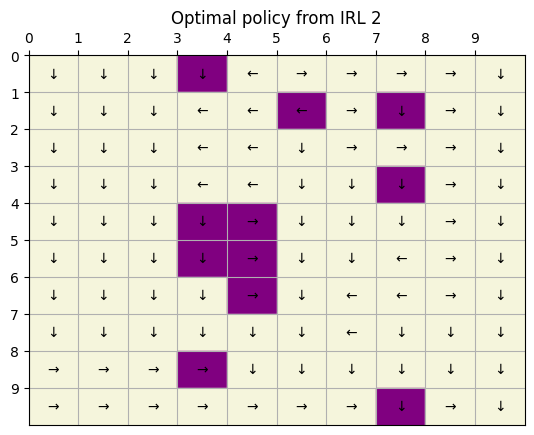

time: 7.25 s (started: 2025-08-08 11:37:31 +00:00)


In [ ]:
### Plotting the optimal policy of the agent

optimal_policy_ag2 = find_policy(gw_irl_2.n_states, gw_irl_2.n_actions,
                                gw_irl_2.transition_probability, rec_reward2,
                                gw_irl_2.discount, stochastic=False)

# Generating the matrix containing the optimal actions for the agent

action_matrix_ag2 = np.zeros((grid_size, grid_size))
for i in range(gw_irl_2.n_states):
    action_matrix_ag2[int(i%grid_size)][int(i/grid_size)] = optimal_policy_ag2[i]

# Plotting
plot_arrow(action_matrix_ag2, "Optimal policy from IRL 2", action_matrix2)


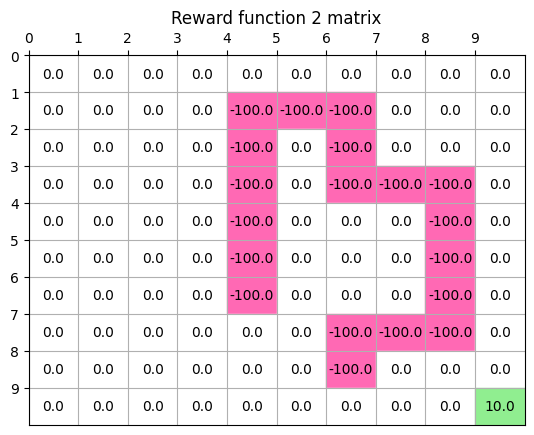

time: 348 ms (started: 2025-08-09 01:31:06 +00:00)


In [ ]:
reward_matrix2 = reward_grid_plot2()

### Q24. Compare the figures of Q9 and Q23 and provide a brief explanation on their similarities and differences. (10 pt)

**Answer:** Both show a trend of moving toward the bottom right corner which is the expected pattern. The majority of the optimal policy above is identical between ground truth and Q23. In both policies, the actor is moving towards the lower right corner of the grid. We color coordinated the actions that are identical and those that differ:

Beige blocks - same as ground truth

Purple blocks - different

With 11 purple blocks, the accuracy is 89% for the extracted reward policy. The "incorrect" actions are close to the "hotpink" areas in reward fucntion 2.

### Q25.  From the figure in question 23, you should observe that the optimal policy of the agent has two major discrepancies. (50 pt)

Please identify and provide the
 causes for these two discrepancies. One of the discrepancy can be fixed easily by a slight modification to the value iteration algorithm. Perform this modification and re-run the modified value iteration algorithm to compute the optimal policy of the agent. Also, recompute the maximum accuracy after this modification. Is there a change in maximum accuracy? The second discrepancy is harder to fix and is a limitation of the simple IRL algorithm.

**Answer**:
It appears that the two discrepancies of the optimal policy are

1. The agent is going against what is optimal, such as going in the opposite direction of the positive reward (state 51, etc) or going outside of the grid (state 79). This discrepancy was corrected once we rerun the code with a smaller threshold of 0.00000001.  The maximum accuracy improved from 89% to 95% with this change. With a smaller threshold value, we force the value iteration algorithm to run longer when finding the optimal, instead of stopping too early.

2. The second discrepancy could be a limitation of the IRL algorithm.
This could happen if the mapping from policies to reward functions is not unique. When multiple reward functions lead to similar optimal policy or very similar trajectories, the inverse of the process could not uniquely identify the true reward function from observed expert policy alone, hence the accuracy suffers.




Number of iterations:  195 of steps =  inf , delta =  9.434472758584889e-09


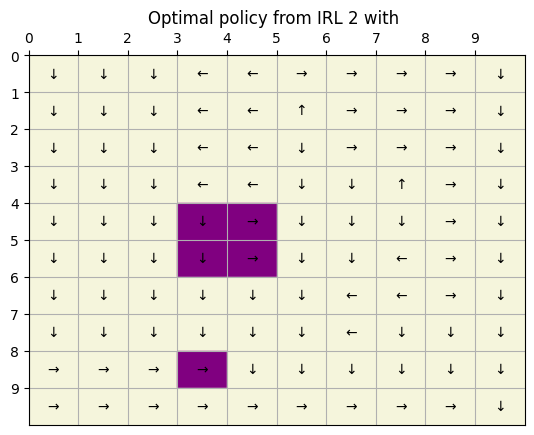

time: 26.2 s (started: 2025-08-09 01:38:53 +00:00)


In [ ]:
### Plotting the optimal policy of the agent

optimal_policy_ag_mod = find_policy(gw_irl_2.n_states, gw_irl_2.n_actions,
                                gw_irl_2.transition_probability, rec_reward2,
                                gw_irl_2.discount, threshold=0.00000001, stochastic=False)

# Generating the matrix containing the optimal actions for the agent

action_matrix_ag2_mod = np.zeros((grid_size, grid_size))
for i in range(gw_irl_2.n_states):
    action_matrix_ag2_mod[int(i%grid_size)][int(i/grid_size)] = optimal_policy_ag_mod[i]

# Plotting
plot_arrow(action_matrix_ag2_mod, "Optimal policy from IRL 2 with ", action_matrix2)
